In [1]:
import torch
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import time
import copy

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls "/content/drive/My Drive/Colab Notebooks/Garbage_Dataset_Classification/images"

test  train  val


In [4]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

In [5]:
data_dir = "/content/drive/My Drive/Colab Notebooks/Garbage_Dataset_Classification/images"
os.listdir(data_dir)

['test', 'train', 'val']

In [6]:
sets = ["train", "val", "test"]

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in sets}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=4) for x in sets}
dataset_sizes = {x: len(image_datasets[x]) for x in sets}
class_names = image_datasets["train"].classes

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [8]:
class_names

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

In [9]:
#load pre trained model

model_ft = torchvision.models.densenet121(pretrained=True)
num_ftrs = model_ft.classifier.in_features
model_ft.classifier = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, len(class_names)),
)

model_ft.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.Adam(model_ft.parameters(), lr=0.001, amsgrad=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 179MB/s]


In [10]:
def train_model(model, criterion, optimizer, num_epochs=25):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0

    for epoch in range(num_epochs):
        print(f"Epoch {epoch}/{num_epochs -1}")
        print("----------------------------------------")

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()


                with torch.set_grad_enabled(phase =='train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs,1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase}, Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()
    print(f"Best val acc: {best_acc:4f}")

    model.load_state_dict(best_model_wts)
    return model

In [11]:
model_ft = train_model(model_ft, criterion, optimizer_ft, num_epochs=25)

Epoch 0/24
----------------------------------------
train, Loss: 1.1167 Acc: 0.5922
val, Loss: 0.7827 Acc: 0.7183

Epoch 1/24
----------------------------------------
train, Loss: 0.8845 Acc: 0.6880
val, Loss: 0.8149 Acc: 0.7269

Epoch 2/24
----------------------------------------
train, Loss: 0.7774 Acc: 0.7291
val, Loss: 0.6053 Acc: 0.7939

Epoch 3/24
----------------------------------------
train, Loss: 0.7056 Acc: 0.7546
val, Loss: 0.8272 Acc: 0.7687

Epoch 4/24
----------------------------------------
train, Loss: 0.6626 Acc: 0.7715
val, Loss: 0.5593 Acc: 0.8228

Epoch 5/24
----------------------------------------
train, Loss: 0.6167 Acc: 0.7857
val, Loss: 0.4313 Acc: 0.8494

Epoch 6/24
----------------------------------------
train, Loss: 0.5885 Acc: 0.7946
val, Loss: 0.4143 Acc: 0.8653

Epoch 7/24
----------------------------------------
train, Loss: 0.5509 Acc: 0.8116
val, Loss: 0.5213 Acc: 0.8184

Epoch 8/24
----------------------------------------
train, Loss: 0.5338 Acc: 0.8

In [12]:
def evaluate_model(model):
  model.eval()
  running_corrects = 0

  for inputs, labels in dataloaders["test"]:
    inputs = inputs.to(device)
    labels = labels.to(device)

    with torch.inference_mode():
      outputs = model(inputs)
      _, preds = torch.max(outputs, 1)

    running_corrects += torch.sum(preds == labels.data)

  test_acc = running_corrects.double() / dataset_sizes["test"]

  print(f"Test Acc: {test_acc:4f}")

evaluate_model(model_ft)

Test Acc: 0.936827


In [13]:
torch.save(model_ft.state_dict(), "gargabes_recycle_model.pth")

In [14]:
loaded_model = torch.load("gargabes_recycle_model.pth")

In [15]:
loaded_model = models.densenet121(pretrained=False)
num_ftrs = loaded_model.classifier.in_features
loaded_model.classifier = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, len(class_names)),
)

loaded_model.load_state_dict(torch.load("gargabes_recycle_model.pth"))
loaded_model.to(device)
loaded_model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [16]:
def load_image(image_path):
  transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
  ])

  image = Image.open(image_path)
  image = transform(image).unsqueeze(0)

  return image

In [17]:
def imshow(inp, title=None):
  inp = inp.numpy().transpose([1,2,0])
  mean = np.array([0.485, 0.456, 0.406])
  std = np.array([0.229, 0.224, 0.225])
  inp = std * inp + mean
  inp = np.clip(inp, 0, 1)
  plt.imshow(inp)
  if title is not None:
    plt.title(title)
  plt.pause(0.001)

In [18]:
def predict_image(model, image):
  model.eval()
  image = image.to(device)
  with torch.inference_mode():
    outputs = model(image)
    _, preds = torch.max(outputs, 1)
    return class_names[preds[0]], preds[0]

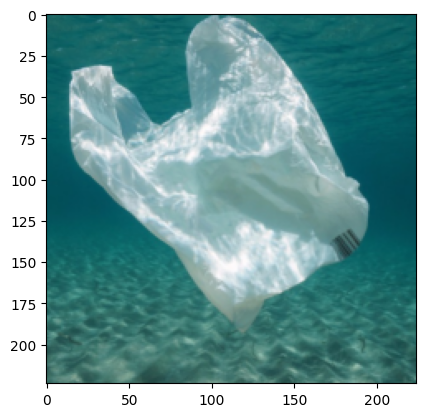

Predicted class: plastic, Index: 4


In [19]:
image_path = "picture1.jpg"
image = load_image(image_path)

plt.figure()
imshow(image.squeeze())
plt.show()

predicted_class, predicted_class_idx = predict_image(loaded_model, image)
print(f"Predicted class: {predicted_class}, Index: {predicted_class_idx}")